## Neural Network with Pytorch

### Roadmap

#### Phase 1 - Data preparation for PyTorch
* Convert DataFrames to tensors
* Create Dataset & DataLoader
* Handle categorical encoding already done

#### Phase 2 - Neural network architecture
* Simple but effective Multilayer Perceptron (MLP)
* Proper activation functions
* Regularization

#### Phase 3 - Training loop
* Loss function
* Optimizer
* Validation monitoring
* Early stopping

#### Phase 4 - Evaluation
* Accuracy
* ROC-AUC
* Comparison vs Logistic Regression

#### Phase 5 - Interpretation
* Why NN helps / doesn’t help
* When NN is worth it in sports data

----------------------------------------------------------------------------------------------------------

### Phase 1 - Data Preparation

In [12]:
import sys
from pathlib import Path

# Regarding Tennis_ML_Project/Notebooks, scr is a sibbling, not a child, 
# so we need to add the parent of Notebooks to the path so that we can import from src

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))


In [13]:
import src
print("src imported correctly:", src)


src imported correctly: <module 'src' from 'c:\\Users\\X421IA\\Desktop\\Learning Projects\\Tennis_ML_Project\\src\\__init__.py'>


In [14]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Import our own modules
from src.dataset import MatchDataset
from src.models import MatchOutcomeNN
from src.train import train_one_epoch, evaluate


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


#### Load processed data

In [16]:
X_train_df = pd.read_csv("../data/processed/X_train.csv")
X_val_df = pd.read_csv("../data/processed/X_val.csv")
X_test_df = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_val = pd.read_csv("../data/processed/y_val.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(X_train_df.shape, X_val_df.shape, X_test_df.shape)


(25630, 12) (5972, 12) (6152, 12)


#### Convert to PyTorch tensors

In [17]:
X_train_t = torch.tensor(X_train_df.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val_df.values, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test_df.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print(X_train_t.shape, y_train_t.shape)


torch.Size([25630, 12]) torch.Size([25630])


#### Create datasets and dataloaders

In [18]:
BATCH_SIZE = 64

train_dataset = MatchDataset(X_train_t, y_train_t)
val_dataset = MatchDataset(X_val_t, y_val_t)
test_dataset = MatchDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


#### Initialize the neural network

In [19]:
input_dim = X_train_t.shape[1]

model = MatchOutcomeNN(input_dim).to(device)
model


MatchOutcomeNN(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

#### Loss function and optimizer

In [20]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


#### Training configuration

In [21]:
EPOCHS = 20
best_val_auc = 0.0
best_state_dict = None


* 20 epochs is plenty for tabular data
* We’ll keep the best model by validation AUC

#### Training loop with validation

In [22]:
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(     # train using training data (2018-2022)
        model, 
        train_loader,
        optimizer, 
        criterion, 
        device)
    
    val_acc, val_auc, *_, = evaluate(      # evaluate on validation data (2023)
        model, 
        val_loader, 
        device)
    
    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val AUC: {val_auc:.4f}"
    )

    # Save best model (by AUC)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state_dict = model.state_dict()
    
    

Epoch 01 | Train Loss: 0.6672 | Val Acc: 0.6155 | Val AUC: 0.6702
Epoch 02 | Train Loss: 0.6524 | Val Acc: 0.6177 | Val AUC: 0.6740
Epoch 03 | Train Loss: 0.6490 | Val Acc: 0.6186 | Val AUC: 0.6746
Epoch 04 | Train Loss: 0.6476 | Val Acc: 0.6204 | Val AUC: 0.6749
Epoch 05 | Train Loss: 0.6451 | Val Acc: 0.6222 | Val AUC: 0.6765
Epoch 06 | Train Loss: 0.6441 | Val Acc: 0.6227 | Val AUC: 0.6762
Epoch 07 | Train Loss: 0.6435 | Val Acc: 0.6246 | Val AUC: 0.6766
Epoch 08 | Train Loss: 0.6435 | Val Acc: 0.6253 | Val AUC: 0.6770
Epoch 09 | Train Loss: 0.6429 | Val Acc: 0.6229 | Val AUC: 0.6779
Epoch 10 | Train Loss: 0.6410 | Val Acc: 0.6242 | Val AUC: 0.6778
Epoch 11 | Train Loss: 0.6390 | Val Acc: 0.6264 | Val AUC: 0.6779
Epoch 12 | Train Loss: 0.6408 | Val Acc: 0.6269 | Val AUC: 0.6783
Epoch 13 | Train Loss: 0.6408 | Val Acc: 0.6266 | Val AUC: 0.6784
Epoch 14 | Train Loss: 0.6407 | Val Acc: 0.6286 | Val AUC: 0.6788
Epoch 15 | Train Loss: 0.6408 | Val Acc: 0.6309 | Val AUC: 0.6783
Epoch 16 |

* Train loss ↓ steadily
* Validation AUC ↑ steadily, no wildly fluctuations
* No sudden drops
* No divergence between train & val

#### Load best model

In [23]:
model.load_state_dict(best_state_dict)
print("Best validation AUC:", best_val_auc)


Best validation AUC: 0.6795059238267083


* +0.0084 AUC improvement over Logistic Regression (baseline) 
* Meaninful in sports prediction


The NN is likely capturing non-linear interactions such as:
 * Rank × surface
 * Cluster × height
 * Rank × cluster_diff
 * Age × tournament level

A shallow neural network was able to modestly outperform a linear baseline, suggesting the presence of non-linear relationships between player attributes and match context.

#### Evaluate on test set

In [25]:
test_acc, test_auc, *_ = evaluate(
    model,
    test_loader,
    device
)

print(f"Neural Network Test Accuracy (2024): {test_acc:.4f}")
print(f"Neural Network Test ROC-AUC (2024): {test_auc:.4f}")

Neural Network Test Accuracy (2024): 0.6265
Neural Network Test ROC-AUC (2024): 0.6784


A shallow neural network implemented in PyTorch outperformed a logistic regression baseline, improving ROC-AUC from 0.67 to 0.68 on a strictly held-out 2024 season.

## Threshold Tuning

We want to improve Accuracy. We'll work on the validation set only to choose the best threshold. Then we will apply that threshold to the test set.

In [26]:
# Default evaluation (threshold = 0.5)
val_acc_default, val_auc, val_probs, val_targets = evaluate(
    model, val_loader, device, threshold=0.5
)

print("Validation Accuracy (0.5):", val_acc_default)
print("Validation ROC-AUC:", val_auc)


Validation Accuracy (0.5): 0.629939718687207
Validation ROC-AUC: 0.6795059238267083


#### Precision-Recall Curve

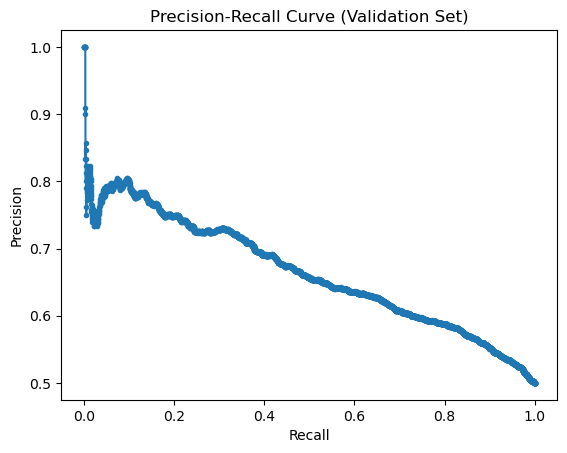

In [27]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(val_targets, val_probs)

plt.figure()
plt.plot(recalls, precisions, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Validation Set)')
plt.show()

In [28]:
print("Thresholds:", thresholds)

Thresholds: [0.02719754 0.02935016 0.03812161 ... 0.954266   0.9584637  0.9648573 ]


#### Find Threshold Maximizing F1

In [29]:
f1_scores = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    f1 = f1_score(val_targets, preds)
    f1_scores.append(f1)

f1_scores = np.array(f1_scores)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best Threshold: {best_threshold:.4f} | Best F1 Score: {best_f1:.4f}")

Best Threshold: 0.3329 | Best F1 Score: 0.6859


#### Compare with default threshold 0.5

In [30]:
default_f1 = f1_score(val_targets, (val_probs >= 0.5).astype(int))
print("F1 Score at 0.5 threshold:", default_f1)
print("F1 Score at best threshold:", best_f1)

F1 Score at 0.5 threshold: 0.625804266847274
F1 Score at best threshold: 0.6859215127574149


### Apply best threshold to Test Set

In [32]:
test_acc_default, test_auc, test_probs, test_targets = evaluate(
    model, test_loader, device, threshold=0.5
)

test_acc_best, _, _, _ = evaluate(
    model, test_loader, device, threshold=best_threshold
)

test_f1_default = f1_score(test_targets, (test_probs >= 0.5).astype(int))
test_f1_best = f1_score(test_targets, (test_probs >= best_threshold).astype(int))

print("Test Accuracy (0.5):", test_acc_default)
print("Test Accuracy (optimized):", test_acc_best)
print("-------------------------------")
print("Test F1 (0.5):", test_f1_default)
print("Test F1 (optimized):", test_f1_best)
print("-------------------------------")
print("Test ROC-AUC:", test_auc)


Test Accuracy (0.5): 0.6264629388816645
Test Accuracy (optimized): 0.5864759427828349
-------------------------------
Test F1 (0.5): 0.6221637619204209
Test F1 (optimized): 0.6829511465603191
-------------------------------
Test ROC-AUC: 0.6784268090895409


### F1 vs Threshold Curve

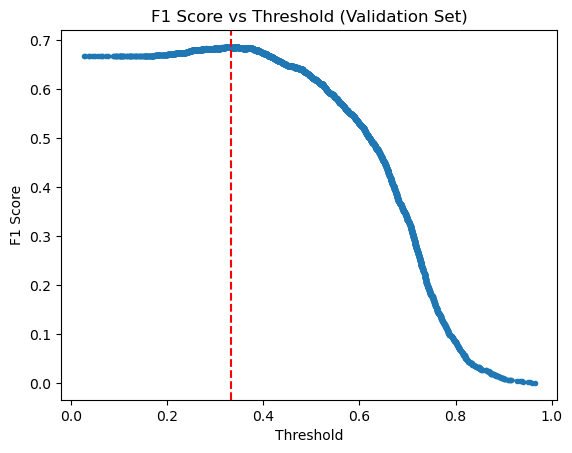

Best threshold: 0.332892
Best validation F1: 0.6859215127574149


In [34]:
plt.figure()
plt.plot(thresholds, f1_scores, marker='.')
plt.axvline(best_threshold, linestyle='--', color='red')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold (Validation Set)")
plt.show()

print("Best threshold:", best_threshold)
print("Best validation F1:", best_f1)

In [35]:
default_idx = np.argmin(np.abs(thresholds - 0.5))
print("F1 at threshold 0.5:", f1_scores[default_idx])


F1 at threshold 0.5: 0.625804266847274


I analyzed the effect of decision boundary tuning by studying F1 as a function of threshold.